# Preprocesado con diferenciación fraccional de ventana fija (FFD)

Este notebook prepara un conjunto de datos financiero usando **diferenciación fraccional de ventana fija** (*Fixed-Window Fractional Differentiation*).

## ¿Por qué?

Las series financieras (log-precios) suelen tener mucha memoria pero no son estacionarias. La diferenciación entera (retornos) hace la serie estacionaria pero destruye toda la memoria. La diferenciación fraccional busca un punto intermedio: aplicar una `d` entre 0 y 1 que haga la serie estacionaria conservando memoria de largo plazo.



## 1. Imports

In [2]:
# ============================================================
# IMPORTS
# ============================================================

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import adfuller

warnings.simplefilter(action="ignore", category=FutureWarning)

print("Imports cargados correctamente.")

Imports cargados correctamente.


## 2. Descarga de datos



In [35]:
# ============================================================
# DESCARGA DE DATOS
# ============================================================

start_date = "1945-01-01"

tickers_validos = [
    "AEP", "BA", "CAT", "CNP", "CVX", "DIS", "DTE", "ED",
    "GD", "GE", "HON", "HPQ", "IBM", "IP", "JNJ", "KO",
    "KR", "MMM", "MO", "MRK", "MSI", "PG", "XOM"
]

#precios_close = yf.download(tickers_validos, start=start_date, auto_adjust=True, progress=True)["Close"]
precios_close = pd.read_csv('precios_activos.csv', header=0, index_col=0)

precios_close.dropna(axis=1, inplace=True)

print("Dimensiones de precios_close:", precios_close.shape)
print("Numero de activos disponibles:", precios_close.shape[1])
print("Activos:", list(precios_close.columns))

Dimensiones de precios_close: (16191, 23)
Numero de activos disponibles: 23
Activos: ['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK', 'MSI', 'PG', 'XOM']


## 3. Cálculo de retornos y log-precios

- Los **retornos logarítmicos** serán la variable objetivo `y`.
- Los **log-precios** serán la serie sobre la que aplicamos FFD para construir `X`.

In [ ]:
# ============================================================
# RETORNOS Y LOG-PRECIOS
# ============================================================

returns    = np.log(precios_close).diff().dropna()
log_prices = np.log(precios_close).dropna()

print("Dimensiones de returns:    ", returns.shape)
print("Dimensiones de log_prices: ", log_prices.shape)
returns.head()

Dimensiones de returns:     (16200, 23)
Dimensiones de log_prices:  (16201, 23)


Ticker,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1962-01-03,-0.001824,0.019802,0.009693,-0.009821,-0.002260,0.013332,-0.008266,0.000000,0.032925,-0.010084,...,-0.013746,-0.015669,-0.022532,0.020792,0.007491,-0.018518,-0.042802,-0.002911,-0.010989,0.014743
1962-01-04,-0.014706,-0.009851,0.025398,0.000000,-0.009090,0.000000,-0.008333,-0.003091,0.004041,-0.011894,...,-0.003467,-0.010578,0.007570,-0.004124,0.000000,0.006985,-0.010255,-0.008784,-0.016714,0.002436
1962-01-05,-0.022473,-0.020001,0.009360,-0.024418,-0.025435,0.003308,-0.021143,-0.021910,0.004023,-0.025977,...,0.010364,-0.016089,-0.022876,-0.025106,-0.026466,0.011533,-0.034462,-0.005899,-0.007047,-0.022141
1962-01-08,-0.007604,0.002521,0.006193,-0.011299,-0.004696,-0.003308,0.002135,0.004735,0.015937,-0.001755,...,-0.020835,-0.016349,-0.010336,-0.004247,-0.005764,-0.006904,0.003044,-0.017912,-0.027241,-0.002492
1962-01-09,-0.007662,0.002516,0.009216,0.000000,0.014019,0.019676,0.002129,-0.001576,0.003944,0.005259,...,-0.014134,0.010929,0.018018,-0.021506,0.000000,-0.018647,0.004549,-0.024391,-0.001454,-0.002497


## 4. Configuración de ventanas



In [ ]:
# ============================================================
# CONFIGURACION DE VENTANAS
# ============================================================

input_window_size = 30
output_window_size = 90

print(f"Ventana de entrada: {input_window_size} dias")
print(f"Ventana de salida:  {output_window_size} dias")

Ventana de entrada: 30 dias
Ventana de salida:  90 dias


## 5. Split temporal único por fechas

Definimos un solo corte por fechas y lo usamos consistentemente para:

1. Ajustar la selección de `d` (solo con train).
2. Hacer el split final de train/val/test del modelo.

Así evitamos el leakage.

Proporciones aproximadas: 72% train, 18% validación, 10% test.

In [ ]:
# ============================================================
# SPLIT TEMPORAL UNICO POR FECHAS (sobre log_prices)
# ============================================================

n_obs = len(log_prices)

train_end_idx = int(n_obs * 0.72)
val_end_idx   = int(n_obs * 0.90)

train_dates = log_prices.index[:train_end_idx]
val_dates   = log_prices.index[train_end_idx:val_end_idx]
test_dates  = log_prices.index[val_end_idx:]

log_prices_train = log_prices.loc[train_dates]
log_prices_val   = log_prices.loc[val_dates]
log_prices_test  = log_prices.loc[test_dates]

print(f"log_prices_train: {log_prices_train.shape}  | {train_dates[0].date()} -> {train_dates[-1].date()}")
print(f"log_prices_val:   {log_prices_val.shape}  | {val_dates[0].date()} -> {val_dates[-1].date()}")
print(f"log_prices_test:  {log_prices_test.shape}  | {test_dates[0].date()} -> {test_dates[-1].date()}")

log_prices_train: (11664, 23)  | 1962-01-02 -> 2008-05-02
log_prices_val:   (2916, 23)  | 2008-05-05 -> 2019-12-02
log_prices_test:  (1621, 23)  | 2019-12-03 -> 2026-05-15


## 6. Funciones de diferenciación fraccional de ventana fija


**Importante**: los pesos se devuelven en **orden natural**: $w_0 = 1$ multiplica al dato más reciente, $w_1$ al dato anterior, etc. `np.convolve` invierte internamente el kernel (es la definición de convolución), así que pasándole los pesos en orden natural se obtiene exactamente la fórmula de López de Prado:

$$\tilde{X}_t = \sum_{k=0}^{l-1} w_k \, X_{t-k}$$

In [4]:
# ============================================================
# FUNCIONES FFD
# ============================================================

def get_fracdiff_weights_ffd(d, threshold=1e-5, max_size=10000):
    """
    Calcula los pesos de la diferenciacion fraccional segun la formula de Lopez de Prado:
        w_0 = 1
        w_k = -w_{k-1} * (d - k + 1) / k

    Se cortan los pesos cuando |w_k| < threshold para limitar el tamano de la ventana.

    Devuelve los pesos en ORDEN NATURAL:
        - w[0] esta pensado para multiplicar al dato MAS RECIENTE (X_t),
        - w[1] al anterior (X_{t-1}), etc.

    np.convolve invierte el kernel internamente, asi que pasandole estos pesos
    en orden natural se obtiene la formula correcta.
    """
    weights = [1.0]
    for k in range(1, max_size):
        next_weight = -weights[-1] * (d - k + 1) / k
        if abs(next_weight) < threshold:
            break
        weights.append(next_weight)
    return np.array(weights, dtype=float)


def frac_diff_ffd_series(series, d, threshold=1e-5, weights=None):
    """
    Aplica diferenciacion fraccional de ventana fija a una serie individual.

    weights: si se pasa precalculado, evita recomputarlo por columna (eficiencia).
    """
    clean_series = series.dropna().astype(float)

    if weights is None:
        weights = get_fracdiff_weights_ffd(d=d, threshold=threshold)
    width = len(weights)

    if width > len(clean_series):
        return pd.Series(index=clean_series.index, dtype=float)

    # np.convolve invierte el kernel internamente: pasandole los pesos en orden
    # natural (w_0 para el dato actual) se obtiene la formula correcta de LdP.
    values = np.convolve(clean_series.values, weights, mode="valid")

    # Primer punto valido: clean_series.index[width - 1].
    valid_index = clean_series.index[width - 1:]
    return pd.Series(values, index=valid_index)


def frac_diff_ffd_dataframe(df, d, threshold=1e-5):
    """
    Aplica FFD a todas las columnas. Calcula los pesos una sola vez.
    """
    weights = get_fracdiff_weights_ffd(d=d, threshold=threshold)
    transformed = {
        col: frac_diff_ffd_series(df[col], d=d, threshold=threshold, weights=weights)
        for col in df.columns
    }
    return pd.DataFrame(transformed).dropna()


def adf_pvalue(series, autolag="BIC"):
    """
    p-valor del test ADF. Devuelve NaN si hay pocos datos o el test falla.
    BIC es mas conservador que AIC en series largas (penaliza lags excesivos).
    """
    clean_series = series.dropna().astype(float)
    if len(clean_series) < 50:
        return np.nan
    try:
        return adfuller(clean_series, autolag=autolag)[1]
    except Exception:
        return np.nan


print("Funciones FFD definidas.")

Funciones FFD definidas.


## 7. Verificación numérica del fix de los pesos



In [ ]:
# ============================================================
# VERIFICACION: convolve == implementacion directa
# ============================================================

def frac_diff_ffd_reference(series, d, threshold=1e-5):
    """Implementacion directa con bucle, literal de la formula de LdP."""
    clean_series = series.dropna().astype(float)
    w = get_fracdiff_weights_ffd(d=d, threshold=threshold)
    width = len(w)
    if width > len(clean_series):
        return pd.Series(index=clean_series.index, dtype=float)
    out = np.empty(len(clean_series) - width + 1)
    vals = clean_series.values
    for idx, t in enumerate(range(width - 1, len(clean_series))):
        # salida[t] = sum_k w[k] * X[t-k]  con k = 0, 1, ..., width-1
        out[idx] = np.dot(w, vals[t - width + 1 : t + 1][::-1])
    return pd.Series(out, index=clean_series.index[width - 1:])


# Comparamos en una sola serie (la primera columna) para varios d.
test_series = log_prices.iloc[:, 0]
for d_test in [0.3, 0.5, 0.7]:
    via_convolve = frac_diff_ffd_series(test_series, d=d_test, threshold=1e-3)
    via_reference = frac_diff_ffd_reference(test_series, d=d_test, threshold=1e-3)
    max_diff = float(np.max(np.abs(via_convolve.values - via_reference.values)))
    print(f"d={d_test}: max_diff entre convolve y referencia = {max_diff:.2e}")

print("\nSi los valores son ~1e-15, la implementacion con convolve es correcta.")

d=0.3: max_diff entre convolve y referencia = 1.89e-15
d=0.5: max_diff entre convolve y referencia = 1.72e-15
d=0.7: max_diff entre convolve y referencia = 1.58e-15

Si los valores son ~1e-15, la implementacion con convolve es correcta.


## 8. Selección automática del parámetro `d` global

Se prueba una rejilla de `d` entre 0 y 1 con saltos de 0.05.

Para cada `d`:

1. Se aplica FFD a los log-precios **solo del tramo de train**.
2. Se hace el test ADF con BIC a cada activo.
3. Se cuenta cuántos son estacionarios al 5%.

Se elige el menor `d` que consigue ≥80% de activos estacionarios.

In [ ]:
# ============================================================
# SELECCION AUTOMATICA DE d GLOBAL
# ============================================================

# Parametros.
FRACDIFF_THRESHOLD   = 1e-5
ADF_ALPHA            = 0.05
MIN_STATIONARY_RATIO = 0.80
ADF_AUTOLAG          = "BIC"

# Rejilla fina de d.
d_values = np.round(np.arange(0.05, 1.0001, 0.05), 2)

# La seleccion se hace usando SOLO log_prices_train.
# Es el mismo tramo de fechas que sera train en el modelo.
selection_rows = []

for d in d_values:
    weights = get_fracdiff_weights_ffd(d=d, threshold=FRACDIFF_THRESHOLD)
    transformed_d = frac_diff_ffd_dataframe(precios_close,d=d,threshold=FRACDIFF_THRESHOLD)

    pvalues = []
    stationary_count = 0
    valid_tests = 0

    for asset in transformed_d.columns:
        p_value = adf_pvalue(transformed_d[asset], autolag=ADF_AUTOLAG)
        if not np.isnan(p_value):
            valid_tests += 1
            pvalues.append(p_value)
            if p_value < ADF_ALPHA:
                stationary_count += 1

    stationary_ratio = stationary_count / valid_tests if valid_tests > 0 else 0.0

    selection_rows.append({
        "d": d,
        "n_weights": len(weights),
        "valid_adf_tests": valid_tests,
        "stationary_count": stationary_count,
        "stationary_ratio": stationary_ratio,
        "mean_adf_pvalue": np.mean(pvalues) if len(pvalues) > 0 else np.nan,
        "median_adf_pvalue": np.median(pvalues) if len(pvalues) > 0 else np.nan,
    })

d_selection_summary = pd.DataFrame(selection_rows)

# Elegimos el menor d que cumple el criterio.
valid_d = d_selection_summary[d_selection_summary["stationary_ratio"] >= MIN_STATIONARY_RATIO]
if len(valid_d) > 0:
    selected_global_d = float(valid_d.iloc[0]["d"])
else:
    selected_global_d = 1.0

FRAC_DIFF_D = selected_global_d

print(f"d global seleccionada: {FRAC_DIFF_D}")
print(f"Criterio: al menos {MIN_STATIONARY_RATIO:.0%} de activos estacionarios (ADF p < {ADF_ALPHA})")
print(f"Autolag ADF: {ADF_AUTOLAG}")
print(f"Threshold pesos: {FRACDIFF_THRESHOLD}")
print()
d_selection_summary

d global seleccionada: 0.35
Criterio: al menos 80% de activos estacionarios (ADF p < 0.05)
Autolag ADF: BIC
Threshold pesos: 1e-05



,d,n_weights,valid_adf_tests,stationary_count,stationary_ratio,mean_adf_pvalue,median_adf_pvalue
0,0.05,3237,23,1,0.043478,5.448140e-01,5.764288e-01
1,0.10,4076,23,0,0.000000,5.037682e-01,5.474212e-01
2,0.15,3901,23,1,0.043478,4.104573e-01,4.347471e-01
3,0.20,3382,23,2,0.086957,2.948547e-01,3.278411e-01
4,0.25,2804,23,7,0.304348,1.851264e-01,9.588712e-02
5,0.30,2275,23,14,0.608696,8.285844e-02,4.078766e-02
6,0.35,1826,23,20,0.869565,2.464781e-02,7.377824e-03
7,0.40,1458,23,23,1.000000,4.128159e-03,1.586063e-04
8,0.45,1163,23,23,1.000000,4.676061e-04,3.135782e-06
9,0.50,927,23,23,1.000000,6.906967e-05,8.750681e-09


## 9. Aplicación de FFD con la `d` seleccionada

Se aplica a TODOS los log-precios (train + val + test). La selección de `d` se hizo solo con train, así que no hay leakage. Lo que aplicamos a val y test es una transformación cuya forma (`d`, pesos) se fijó con información del pasado.

In [ ]:
# ============================================================
# APLICACION DE FFD A TODA LA SERIE
# ============================================================

selected_weights = get_fracdiff_weights_ffd(d=FRAC_DIFF_D,threshold=FRACDIFF_THRESHOLD)
fracdiff_features = frac_diff_ffd_dataframe(log_prices,d=FRAC_DIFF_D,threshold=FRACDIFF_THRESHOLD)

print("Diferenciacion fraccional aplicada.")
print(f"d utilizada:                       {FRAC_DIFF_D}")
print(f"Numero de pesos (longitud ventana): {len(selected_weights)}")
print(f"Observaciones perdidas al inicio:   {len(selected_weights) - 1}")
print(f"Dimensiones de fracdiff_features:   {fracdiff_features.shape}")
fracdiff_features.head()

Diferenciacion fraccional aplicada.
d utilizada:                       0.35
Numero de pesos (longitud ventana): 1826
Observaciones perdidas al inicio:   1825
Dimensiones de fracdiff_features:   (14376, 23)


,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1969-05-12,0.013622,-0.081161,0.043890,-0.062845,0.010976,-0.037928,-0.053224,-0.074119,-0.183702,0.017818,...,0.068755,-0.010683,-0.065199,-0.095876,0.054898,-0.241709,-0.045056,0.032413,-0.046641,-0.041601
1969-05-13,0.035840,-0.068827,0.057202,-0.025782,0.015886,-0.026599,-0.055461,-0.063784,-0.163899,0.016521,...,0.052290,0.004757,-0.092515,-0.100067,0.051364,-0.239493,-0.023143,0.046996,-0.045313,-0.040018
1969-05-14,0.031403,-0.089424,0.075794,-0.021641,0.027553,-0.016991,-0.043005,-0.069213,-0.186745,0.028657,...,0.069184,-0.006212,-0.059946,-0.106061,0.059486,-0.239815,-0.028095,0.050687,-0.021347,-0.036691
1969-05-15,0.018642,-0.082836,0.078642,-0.024167,0.012264,-0.024719,-0.050069,-0.064416,-0.185344,0.013230,...,0.063951,-0.012033,-0.073343,-0.104223,0.043685,-0.238636,-0.036883,0.044993,-0.018372,-0.045705
1969-05-16,0.021044,-0.080484,0.087200,-0.035171,0.007429,-0.019501,-0.048741,-0.072936,-0.167350,0.017446,...,0.080979,-0.006425,-0.057456,-0.100812,0.048168,-0.230649,-0.043371,0.041021,-0.009884,-0.046412


## 10. Comprobación ADF sobre la serie completa transformada

Reportamos el porcentaje de activos estacionarios con la `d` elegida, ahora sobre toda la serie disponible tras FFD.

In [ ]:
# ============================================================
# COMPROBACION ADF FINAL
# ============================================================

final_adf_rows = []

for asset in fracdiff_features.columns:
    p_value = adf_pvalue(fracdiff_features[asset], autolag=ADF_AUTOLAG)
    final_adf_rows.append({
        "asset": asset,
        "selected_global_d": FRAC_DIFF_D,
        "adf_pvalue": p_value,
        "stationary_5pct": (p_value < ADF_ALPHA) if not np.isnan(p_value) else False,
    })

final_adf_summary = pd.DataFrame(final_adf_rows)

print(f"Porcentaje de activos estacionarios al 5% (serie completa): "f"{final_adf_summary['stationary_5pct'].mean():.1%}")
final_adf_summary

Porcentaje de activos estacionarios al 5% (serie completa): 73.9%


,asset,selected_global_d,adf_pvalue,stationary_5pct
0,AEP,0.35,1.522055e-02,True
1,BA,0.35,1.490521e-04,True
2,CAT,0.35,7.572743e-03,True
3,CNP,0.35,4.042654e-04,True
4,CVX,0.35,7.438794e-03,True
5,DIS,0.35,9.485860e-05,True
6,DTE,0.35,7.016920e-02,False
7,ED,0.35,2.769168e-02,True
8,GD,0.35,1.303730e-02,True
9,GE,0.35,8.742170e-04,True


## 11. Visualización: log-precio vs FFD

Para uno de los activos, comparamos visualmente el log-precio original y su versión fracdiff. La serie fracdiff debería verse mucho más estacionaria en media.

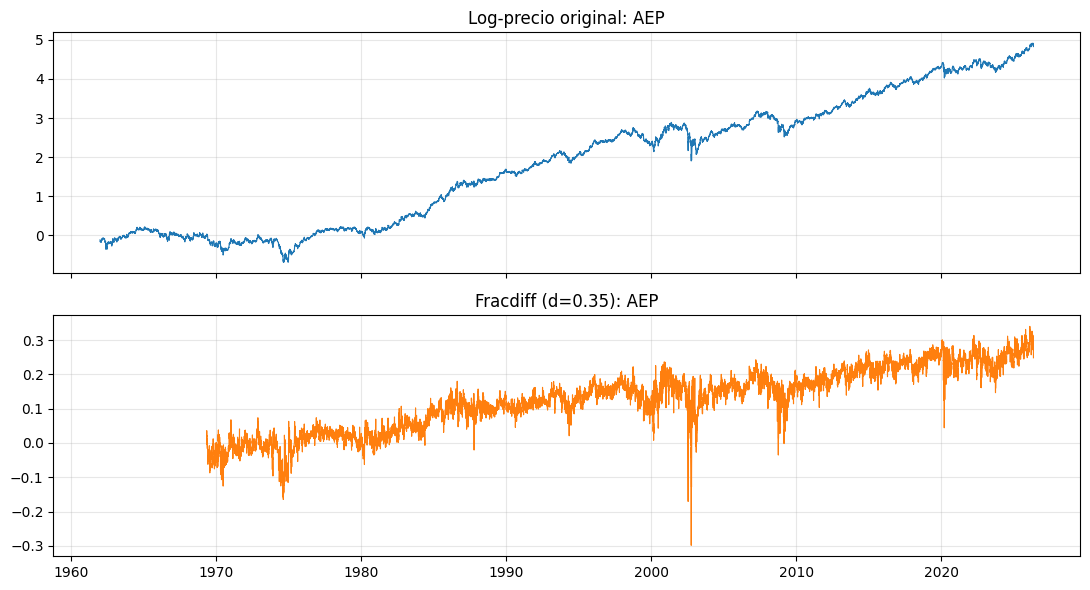

In [ ]:
# ============================================================
# VISUALIZACION DE UN ACTIVO
# ============================================================

asset_to_plot = log_prices.columns[0]

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(log_prices.index, log_prices[asset_to_plot], lw=0.8)
axes[0].set_title(f"Log-precio original: {asset_to_plot}")
axes[0].grid(alpha=0.3)

axes[1].plot(fracdiff_features.index, fracdiff_features[asset_to_plot], lw=0.8, color="C1")
axes[1].set_title(f"Fracdiff (d={FRAC_DIFF_D}): {asset_to_plot}")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Creación de ventanas

- `X` se construye con `fracdiff_features` (entradas preprocesadas).
- `y` se construye con `returns` originales (la variable objetivo no cambia).

Devolvemos también el array de fechas de cada ventana para poder hacer el split por fechas de forma consistente.

In [ ]:
# ============================================================
# CREACION DE VENTANAS
# ============================================================

# Alineamos por indice: returns esta una fila por detras de log_prices
# (la primera fila se pierde al hacer diff()).
common_index = fracdiff_features.index.intersection(returns.index)
X_source = fracdiff_features.loc[common_index]
y_source = returns.loc[common_index]


def create_windows(features, target, input_window_size, output_window_size):
    """
    features: DataFrame que se usara como X (fracdiff de log-precios).
    target:   DataFrame que se usara como y (retornos originales).

    y es la media de los proximos output_window_size dias.
    Devuelve tambien las fechas del ultimo dia de cada ventana de entrada.
    """
    feat_vals = features.values
    targ_vals = target.values
    n = len(feat_vals)
    last_start = n - input_window_size - output_window_size + 1

    X = np.empty((last_start, input_window_size, feat_vals.shape[1]))
    y = np.empty((last_start, targ_vals.shape[1]))

    for i in range(last_start):
        X[i] = feat_vals[i : i + input_window_size]
        y[i] = targ_vals[i + input_window_size : i + input_window_size + output_window_size].mean(axis=0)

    end_of_input_dates = features.index[input_window_size - 1 : input_window_size - 1 + last_start]
    return X, y, end_of_input_dates


X, y, window_dates = create_windows(features=X_source,target=y_source,input_window_size=input_window_size,output_window_size=output_window_size)

print(f"X shape:      {X.shape}")
print(f"y shape:      {y.shape}")
print(f"window_dates: {len(window_dates)} (fecha del ultimo dia de la ventana de entrada)")

X shape:      (14257, 30, 23)
y shape:      (14257, 23)
window_dates: 14257 (fecha del ultimo dia de la ventana de entrada)


## 13. División train / val / test por fechas

Cada ventana se asigna a train, val o test según la fecha del **último día de su entrada**. Las fronteras son las mismas que definimos en la celda 5, así que el `d` ajustado en train se ha entrenado exclusivamente con datos de train.

In [ ]:
# ============================================================
# SPLIT POR FECHAS
# ============================================================

train_mask = window_dates <= train_dates[-1]
val_mask   = (window_dates > train_dates[-1]) & (window_dates <= val_dates[-1])
test_mask  = window_dates > val_dates[-1]

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}  y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}  y_test:  {y_test.shape}")
print()
print(f"Fechas train: {window_dates[train_mask][0].date()} -> {window_dates[train_mask][-1].date()}")
print(f"Fechas val:   {window_dates[val_mask][0].date()} -> {window_dates[val_mask][-1].date()}")
print(f"Fechas test:  {window_dates[test_mask][0].date()} -> {window_dates[test_mask][-1].date()}")

X_train: (9810, 30, 23)  y_train: (9810, 23)
X_val:   (2916, 30, 23)  y_val:   (2916, 23)
X_test:  (1531, 30, 23)  y_test:  (1531, 23)

Fechas train: 1969-06-23 -> 2008-05-02
Fechas val:   2008-05-05 -> 2019-12-02
Fechas test:  2019-12-03 -> 2026-01-06


## 14. Escalado con `StandardScaler`

La fracdiff puede dejar distintas escalas entre activos (depende del nivel del log-precio y de la varianza específica). Para que ningún activo domine el entrenamiento, aplicamos `StandardScaler` ajustado **solo con `X_train`**.

In [ ]:
# ============================================================
# ESCALADO STANDARD SCALER
# ============================================================

n_assets = fracdiff_features.shape[1]
asset_names = list(fracdiff_features.columns)

# Reshape 3D -> 2D para ajustar el scaler por activo (columna).
X_train_2d = X_train.reshape(-1, n_assets)
X_val_2d   = X_val.reshape(-1, n_assets)
X_test_2d  = X_test.reshape(-1, n_assets)

scaler = StandardScaler()
scaler.fit(X_train_2d)

X_train = scaler.transform(X_train_2d).reshape(X_train.shape)
X_val   = scaler.transform(X_val_2d).reshape(X_val.shape)
X_test  = scaler.transform(X_test_2d).reshape(X_test.shape)

print("Escalado completado (ajustado solo con X_train).")
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

Escalado completado (ajustado solo con X_train).
X_train: (9810, 30, 23)
X_val:   (2916, 30, 23)
X_test:  (1531, 30, 23)


## 15. Comprobaciones finales

In [ ]:
# ============================================================
# COMPROBACIONES FINALES
# ============================================================

assert X_train.shape[1:] == (input_window_size, n_assets)
assert X_val.shape[1:]   == (input_window_size, n_assets)
assert X_test.shape[1:]  == (input_window_size, n_assets)

assert y_train.shape[1] == n_assets
assert y_val.shape[1]   == n_assets
assert y_test.shape[1]  == n_assets

for name, arr in [("X_train", X_train), ("X_val", X_val), ("X_test", X_test),
                  ("y_train", y_train), ("y_val", y_val), ("y_test", y_test)]:
    assert np.isfinite(arr).all(), f"{name} contiene NaN o inf"

print("Preparacion de datos correcta.\n")
print("Resumen del experimento")
print("-----------------------")
print(f"Ventana de entrada:          {input_window_size} dias")
print(f"Ventana de salida:           {output_window_size} dias")
print(f"d global seleccionada:       {FRAC_DIFF_D}")
print(f"Threshold de pesos:          {FRACDIFF_THRESHOLD}")
print(f"Numero de pesos (ventana):   {len(selected_weights)}")
print(f"Numero de activos:           {n_assets}")
print(f"Nombres activos:             {asset_names}")
print()
print("Dimensiones")
print("-----------------------")
print(f"X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}   y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

Preparacion de datos correcta.

Resumen del experimento
-----------------------
Ventana de entrada:          30 dias
Ventana de salida:           90 dias
d global seleccionada:       0.35
Threshold de pesos:          1e-05
Numero de pesos (ventana):   1826
Numero de activos:           23
Nombres activos:             ['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK', 'MSI', 'PG', 'XOM']

Dimensiones
-----------------------
X_train: (9810, 30, 23)   y_train: (9810, 23)
X_val:   (2916, 30, 23)   y_val:   (2916, 23)
X_test:  (1531, 30, 23)   y_test:  (1531, 23)


## 16. Aplicación al taller

A partir de los precios de los 23 activos, debemos realizar el preprocesado de la diferenciación fraccional para cada activo. En apartados posteriores se ha designado como el valor d óptimo 0.35. En este caso usaremos el valor 0.4 que es el valor teórico óptimo según Lopez de Prado. Esta transformación se aplicará a cada uno de los 23 activos sobre el logaritmo de sus precios. Es en definitiva, una forma alternativa de "calcular los retornos".

In [45]:
# Para cada activo
df_new = pd.DataFrame()

for activo in precios_close.columns:
    df_new[activo] = frac_diff_ffd_series(np.log(precios_close[activo]), 0.4, threshold=1e-5, weights=None)

En los siguientes gráficos se muestra para el activo AEP a modo de ejemplo:

1. La evolución de los precios
2. La evolución de los retornos obtenidos gracias a la diferenciación fraccional
3. la evolución de los retornos logarítmicos habituales

En el caso de los retornos logarítmicos diferenciados fraccionalmente podemos ver que se mantiene la tendencia alcista de los precios.

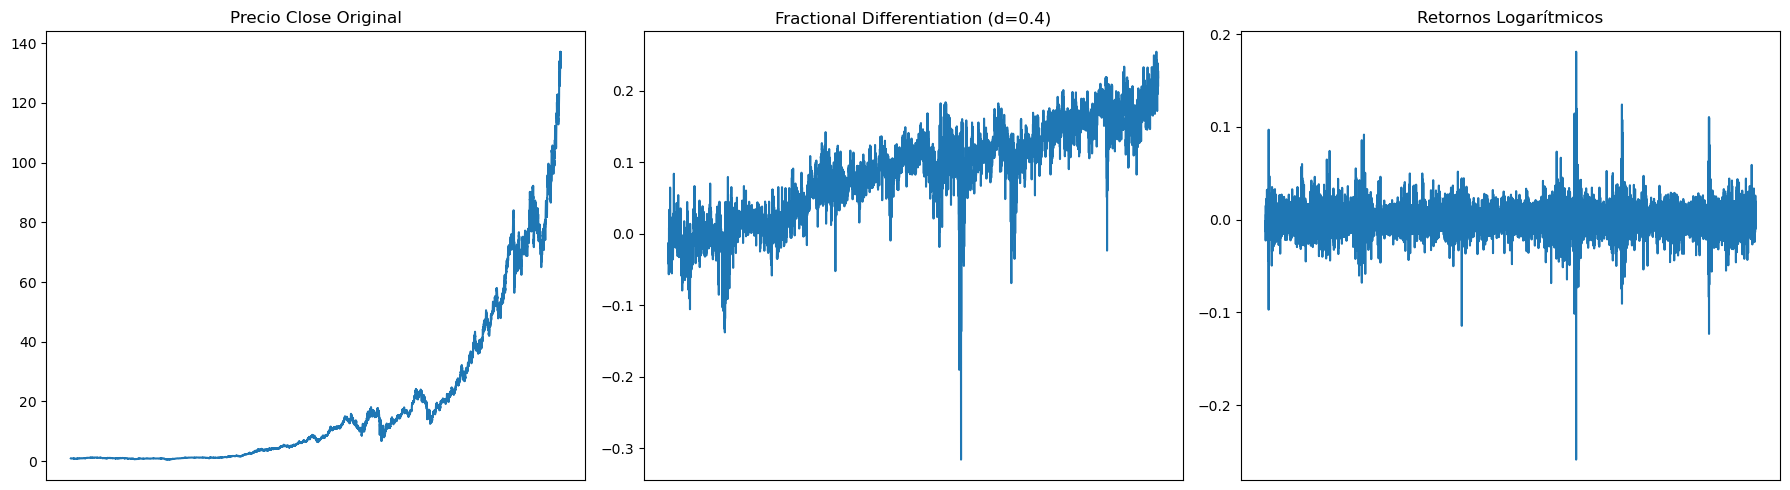

In [47]:
# --- Fraccional differentiation ---
df_new = pd.DataFrame()

for activo in precios_close.columns:
    df_new[activo] = frac_diff_ffd_series(np.log(precios_close[activo]), 0.4, threshold=1e-5, weights=None)

# --- Retornos logarítmicos ---
retornos_lol = np.log(precios_close).diff().dropna()

# --- Crear figura con 1 fila y 3 columnas ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Serie original
axes[0].plot(precios_close.iloc[:, 0])
axes[0].set_title("Precio Close Original")
axes[0].set_xticks([])

# 2. Serie con fractional differentiation
axes[1].plot(df_new[df_new.columns[0]])
axes[1].set_title("Fractional Differentiation (d=0.4)")
axes[1].set_xticks([])

# 3. Retornos logarítmicos
axes[2].plot(retornos_lol[df_new.columns[0]])
axes[2].set_title("Retornos Logarítmicos")
axes[2].set_xticks([])

# Ajuste automático de espacios
plt.tight_layout()

plt.show()

In [ ]:
# Guardamos los datos
df_new.to_csv('precios_diferenciados_log.csv')